In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/Mental Health.csv')
df

,posts,predicted,intensity
0,I know as parent of child with down syndrome t...,negative,-1
1,but in my heart I know this is the future prom...,neutral,0
2,I have mylefibrosis which turn to leukemia the...,negative,-1
3,from one of my health group subject wayne dyer...,neutral,0
4,gmos now link to leukemia http nsnbc I 2013 07...,neutral,0
...,...,...,...
10387,hey everyone I am a 25 year old male I work ou...,negative,-1
10388,have surgery for stage 1 colon cancer 1 year a...,very negative,-2
10389,the doctor advise we he could not remove the a...,neutral,0
10390,my 66 year old father have been through so muc...,neutral,0


IMPORTING LIBRARIES

In [ ]:
df['predicted'].value_counts()

,count
predicted,
neutral,4375
negative,4112
very negative,1155
positive,750


In [ ]:
df.info()
df.shape

df['intensity'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10392 entries, 0 to 10391
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   posts      10391 non-null  object
 1   predicted  10392 non-null  object
 2   intensity  10392 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 243.7+ KB


,count
intensity,
0,4375
-1,4112
-2,1155
1,750


In [ ]:
df.isnull().sum()
df.duplicated().sum()
df=df.dropna()

In [ ]:
df.isnull().sum()

,0
posts,0
predicted,0
intensity,0


In [ ]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download("stopwords")

df["posts"] = df["posts"].str.lower()
df["posts"] = df["posts"].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', str(x)))
df["posts"] = df["posts"].apply(lambda x: re.sub(r'<.*?>', '', x))
df["posts"] = df["posts"].apply(lambda x: re.sub(r"[^\w\s']", "", x))
df["posts"] = df["posts"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df["posts"] = df["posts"].apply(word_tokenize)
stop_words = set(stopwords.words("english"))
keep_words = {
    "not", "no", "nor", "never",
    "don't", "didn't", "doesn't",
    "can't", "won't", "isn't",
    "aren't", "wasn't", "weren't",
    "couldn't", "shouldn't", "wouldn't",
    "haven't", "hasn't", "hadn't"
}
custom_stopwords = stop_words - keep_words
df["posts"] = df["posts"].apply(lambda words: [word for word in words if word.lower() not in custom_stopwords])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_3105/3688988119.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["posts"] = df["posts"].str.lower()
/tmp/ipykernel_3105/3688988119.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

LEMMATIZATION

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

df['posts'] = df['posts'].apply(
    lambda x: [lemmatizer.lemmatize(word, pos='v') for word in x]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipykernel_3105/2529122926.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['posts'] = df['posts'].apply(


In [ ]:
X=df['posts']
y=df['intensity']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)

In [ ]:
!pip install gensim

In [ ]:
sentences = df['posts'].tolist()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_pad,
    y_train
)

In [ ]:
pd.Series(y_train_balanced).value_counts()

,count
0,3485
1,3485
2,3485
3,3485


In [ ]:
df['predicted'].value_counts()

,count
predicted,
neutral,4374
negative,4112
very negative,1155
positive,750


In [ ]:
from gensim.models import Word2Vec
skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [ ]:
import numpy as np
embedding_dim = skipgram_model.vector_size
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix_skipgram = np.zeros((vocab_size, embedding_dim))
for word, index in tokenizer.word_index.items():
    if word in skipgram_model.wv:
        embedding_matrix_skipgram[index] = skipgram_model.wv[word]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
skipgram_lstm = Sequential()
skipgram_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix_skipgram],
        trainable=False
    )
)
skipgram_lstm.add(
    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
skipgram_lstm.add(Dense(64, activation='relu'))
skipgram_lstm.add(Dropout(0.5))
skipgram_lstm.add(Dense(len(np.unique(y)), activation='softmax'))

In [ ]:
skipgram_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_skip_lstm = skipgram_lstm.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 108s 235ms/step - accuracy: 0.5424 - loss: 1.0715 - val_accuracy: 0.5392 - val_loss: 1.0264
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 96s 220ms/step - accuracy: 0.6076 - loss: 0.9546 - val_accuracy: 0.6542 - val_loss: 0.8360
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 97s 223ms/step - accuracy: 0.6471 - loss: 0.8878 - val_accuracy: 0.6287 - val_loss: 0.9073
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 142s 223ms/step - accuracy: 0.6711 - loss: 0.8330 - val_accuracy: 0.6061 - val_loss: 0.8651
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 99s 228ms/step - accuracy: 0.6900 - loss: 0.7831 - val_accuracy: 0.6450 - val_loss: 0.8133
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 138s 219ms/step - accuracy: 0.7051 - loss: 0.7485 - val_accuracy: 0.6633 - val_loss: 0.7849
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 97s 221ms/step - accuracy: 0.7236 - loss: 0.7024 - val_accuracy: 0.6681 - val_loss: 0.7838
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 141s 220ms/step - accuracy: 0.7399 - los

In [ ]:
loss, accuracy = skipgram_lstm.evaluate(X_test_pad, y_test)
print("Skip-Gram + LSTM Accuracy:", accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6840 - loss: 0.7812
Skip-Gram + LSTM Accuracy: 0.6839826703071594


In [ ]:
sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = skipgram_lstm.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
Predicted Label: -2


In [ ]:
from sklearn.metrics import classification_report
y_pred_prob = skipgram_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
              precision    recall  f1-score   support

           0       0.55      0.82      0.66       246
           1       0.67      0.66      0.67       811
           2       0.85      0.68      0.75       889
           3       0.40      0.62      0.49       133

    accuracy                           0.68      2079
   macro avg       0.62      0.69      0.64      2079
weighted avg       0.71      0.68      0.69      2079



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[201  29   3  13]
 [137 537  91  46]
 [ 15 209 602  63]
 [ 10  25  16  82]]


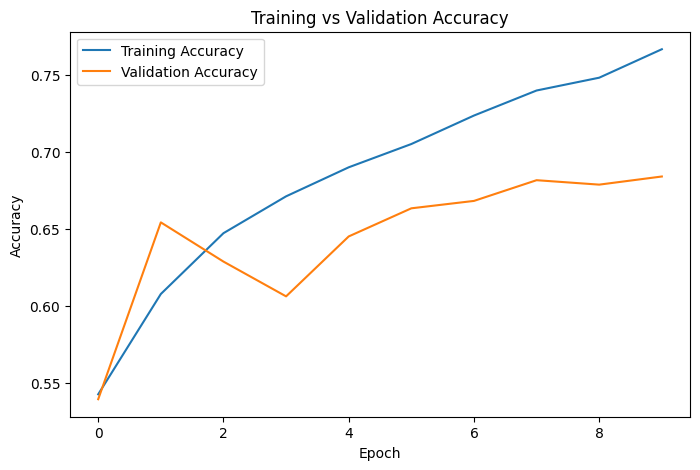

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_skip_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_skip_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

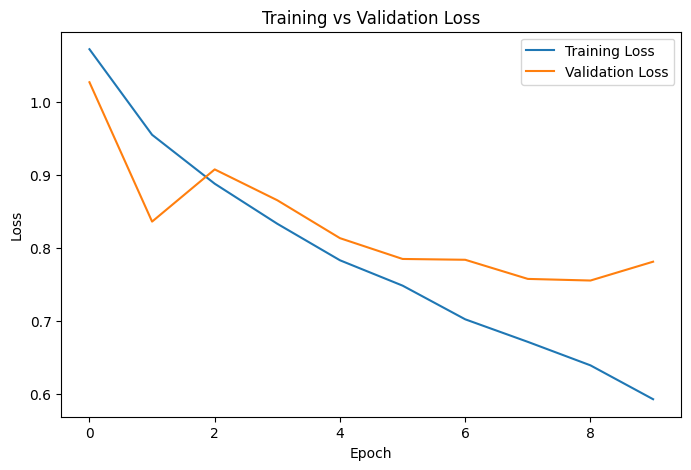

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_skip_lstm.history['loss'], label='Training Loss')
plt.plot(history_skip_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

testing a dataset


In [ ]:

pred = skipgram_lstm.predict(X_test_pad)

pred_labels = np.argmax(pred, axis=1)

predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)

result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})

print(result.head(20))

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
    Actual  Predicted
0        0          0
1       -2         -2
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1         -2
11       0          0
12      -1         -2
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0


In [ ]:
test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)

pred = skipgram_lstm.predict(pad)
pred_labels = np.argmax(pred, axis=1)

test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-2
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,1
6,I am a new member and hope to find some suppor...,negative,-1,-2
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-2
9,I have mylefibrosis which turn to leukemia the...,negative,-1,0


# GRU-------SKIPGRAM

In [ ]:
from tensorflow.keras.layers import GRU
skipgram_gru = Sequential()
skipgram_gru.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix_skipgram],
        trainable=False
    )
)
skipgram_gru.add(
    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
skipgram_gru.add(Dense(64, activation='relu'))
skipgram_gru.add(Dropout(0.5))
skipgram_gru.add(Dense(len(np.unique(y)), activation='softmax'))

In [ ]:
skipgram_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_skip_gru = skipgram_gru.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 95s 208ms/step - accuracy: 0.5250 - loss: 1.0960 - val_accuracy: 0.6118 - val_loss: 0.8836
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 139s 201ms/step - accuracy: 0.6222 - loss: 0.9183 - val_accuracy: 0.6340 - val_loss: 0.8260
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 144s 206ms/step - accuracy: 0.6662 - loss: 0.8386 - val_accuracy: 0.6681 - val_loss: 0.7671
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 89s 203ms/step - accuracy: 0.6819 - loss: 0.7939 - val_accuracy: 0.6676 - val_loss: 0.7809
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 142s 205ms/step - accuracy: 0.7082 - loss: 0.7461 - val_accuracy: 0.6316 - val_loss: 0.8447
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 91s 209ms/step - accuracy: 0.7275 - loss: 0.7014 - val_accuracy: 0.6638 - val_loss: 0.7733
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 90s 206ms/step - accuracy: 0.7418 - loss: 0.6553 - val_accuracy: 0.6652 - val_loss: 0.7721
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 89s 205ms/step - accuracy: 0.7615 - loss

In [ ]:
loss, accuracy = skipgram_gru.evaluate(X_test_pad, y_test)
print("Skip-Gram + GRU Accuracy:", accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6883 - loss: 0.7665
Skip-Gram + GRU Accuracy: 0.6883116960525513


In [ ]:
sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = skipgram_gru.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
Predicted Label: 1


In [ ]:
from sklearn.metrics import classification_report
y_pred_prob = skipgram_gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step
              precision    recall  f1-score   support

           0       0.63      0.70      0.66       246
           1       0.70      0.63      0.66       811
           2       0.81      0.75      0.78       889
           3       0.33      0.65      0.44       133

    accuracy                           0.69      2079
   macro avg       0.62      0.68      0.64      2079
weighted avg       0.71      0.69      0.70      2079



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[173  50   3  20]
 [ 89 508 131  83]
 [  9 148 664  68]
 [  4  19  24  86]]


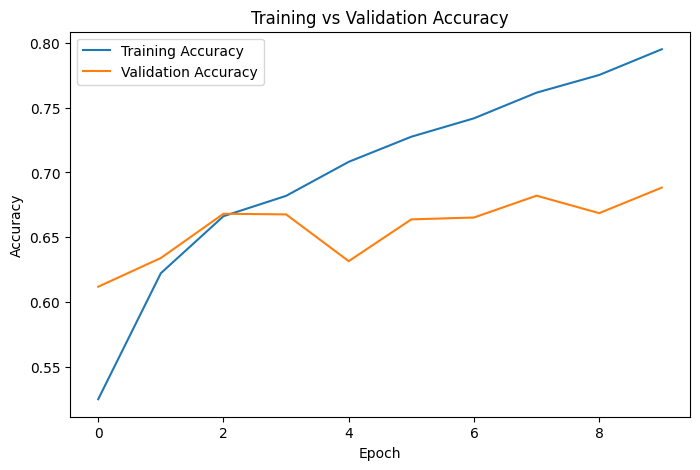

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_skip_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_skip_gru.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

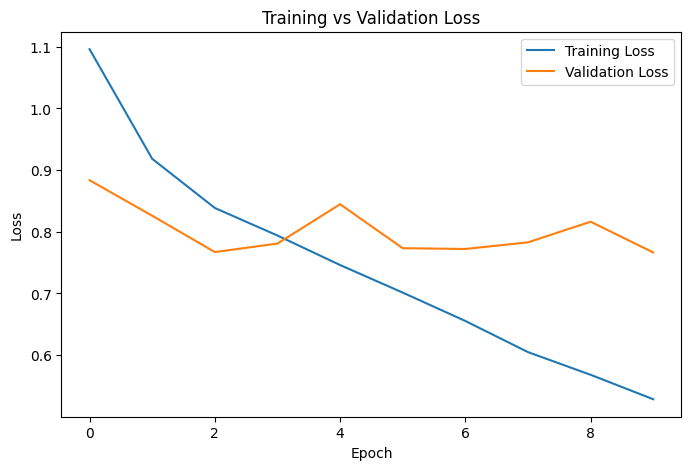

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_skip_gru.history['loss'], label='Training Loss')
plt.plot(history_skip_gru.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:

pred = skipgram_gru.predict(X_test_pad)

pred_labels = np.argmax(pred, axis=1)

predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)

result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})

print(result.head(20))

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
    Actual  Predicted
0        0          0
1       -2         -2
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1          1
11       0          0
12      -1         -1
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0


In [ ]:
test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)

pred = skipgram_gru.predict(pad)
pred_labels = np.argmax(pred, axis=1)

test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-1
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,1
6,I am a new member and hope to find some suppor...,negative,-1,1
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-2
9,I have mylefibrosis which turn to leukemia the...,negative,-1,0


# SKIPGRAM---Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional
skipgram_bilstm = Sequential()
skipgram_bilstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix_skipgram],
        trainable=False
    )
)
skipgram_bilstm.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)
skipgram_bilstm.add(Dense(64, activation='relu'))
skipgram_bilstm.add(Dropout(0.5))
skipgram_bilstm.add(Dense(len(np.unique(y)), activation='softmax'))

In [ ]:
skipgram_bilstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_skip_bilstm = skipgram_bilstm.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 207s 452ms/step - accuracy: 0.5511 - loss: 1.0556 - val_accuracy: 0.6546 - val_loss: 0.8022
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 202s 453ms/step - accuracy: 0.6316 - loss: 0.9109 - val_accuracy: 0.6696 - val_loss: 0.7774
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 194s 444ms/step - accuracy: 0.6627 - loss: 0.8452 - val_accuracy: 0.6551 - val_loss: 0.8031
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 193s 442ms/step - accuracy: 0.6862 - loss: 0.7907 - val_accuracy: 0.6825 - val_loss: 0.7583
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 206s 451ms/step - accuracy: 0.7070 - loss: 0.7368 - val_accuracy: 0.6330 - val_loss: 0.8439
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 193s 444ms/step - accuracy: 0.7275 - loss: 0.6953 - val_accuracy: 0.6859 - val_loss: 0.7347
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 203s 446ms/step - accuracy: 0.7457 - loss: 0.6401 - val_accuracy: 0.6647 - val_loss: 0.7951
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 193s 443ms/step - accuracy: 0.7669 -

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.6825 - loss: 0.7940
Skip-Gram + BILSTM Accuracy: 0.682539701461792
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Predicted Label: -2
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step
              precision    recall  f1-score   support

           0       0.59      0.79      0.68       246
           1       0.67      0.67      0.67       811
           2       0.86      0.67      0.75       889
           3       0.35      0.65      0.45       133

    accuracy                           0.68      2079
   macro avg       0.62      0.69      0.64      2079
weighted avg       0.72      0.68      0.69      2079

[[194  31   5  16]
 [114 544  71  82]
 [ 11 218 595  65]
 [  9  16  22  86]]


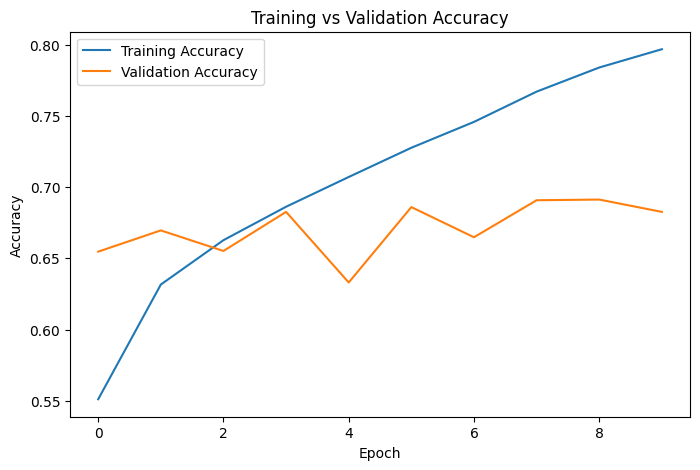

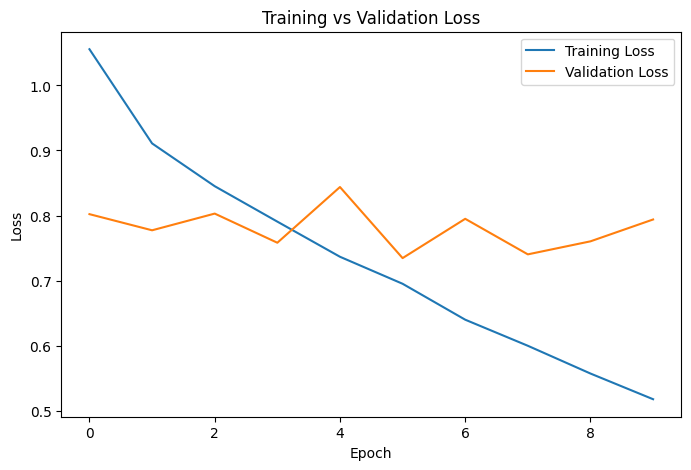

65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step
    Actual  Predicted
0        0          0
1       -2         -2
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1         -2
11       0          0
12      -1         -2
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-2
2,I start with severe headache in jan and was fo...,negative,-1,0
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,1
6,I am a new member and hope to find some suppor...,negative,-1,-2
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-1
9,I have mylefibrosis which turn to leukemia the...,negative,-1,1


In [ ]:
loss, accuracy = skipgram_bilstm.evaluate(X_test_pad, y_test)
print("Skip-Gram + BILSTM Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = skipgram_bilstm.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob = skipgram_bilstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_skip_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_skip_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_skip_bilstm.history['loss'], label='Training Loss')
plt.plot(history_skip_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred = skipgram_bilstm.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))




test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = skipgram_bilstm.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

# Word2Vec-----LSTM

In [ ]:
from gensim.models import Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0
)

In [ ]:
import numpy as np
embedding_dim = w2v_model.vector_size
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, index in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[index] = w2v_model.wv[word]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
w2v_lstm = Sequential()
w2v_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
    )
w2v_lstm.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
w2v_lstm.add(Dense(64, activation='relu'))
w2v_lstm.add(Dropout(0.5))
w2v_lstm.add(Dense(len(np.unique(y)), activation='softmax'))

w2v_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_w2v_lstm =w2v_lstm.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 89s 239ms/step - accuracy: 0.6300 - loss: 0.9086 - val_accuracy: 0.0100 - val_loss: 2.6079
Epoch 2/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 80s 230ms/step - accuracy: 0.6771 - loss: 0.7945 - val_accuracy: 0.0839 - val_loss: 2.1587
Epoch 3/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.7010 - loss: 0.7478 - val_accuracy: 0.1585 - val_loss: 2.0255
Epoch 4/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 80s 230ms/step - accuracy: 0.7137 - loss: 0.7139 - val_accuracy: 0.1944 - val_loss: 1.6954
Epoch 5/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 81s 228ms/step - accuracy: 0.7315 - loss: 0.6703 - val_accuracy: 0.1618 - val_loss: 1.9236
Epoch 6/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 83s 230ms/step - accuracy: 0.7426 - loss: 0.6387 - val_accuracy: 0.2984 - val_loss: 1.5351
Epoch 7/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.7591 - loss: 0.6040 - val_accuracy: 0.3271 - val_loss: 1.5895
Epoch 8/10
349/349 ━━━━━━━━━━━━━━━━━━━━ 81s 229ms/step - accuracy: 0.7669 - loss: 0

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6926 - loss: 0.7808
Word2Vec+ LSTM Accuracy: 0.6926407217979431
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
Predicted Label: -2
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step
              precision    recall  f1-score   support

           0       0.55      0.79      0.65       246
           1       0.65      0.69      0.67       811
           2       0.82      0.73      0.77       889
           3       0.57      0.30      0.39       133

    accuracy                           0.69      2079
   macro avg       0.65      0.63      0.62      2079
weighted avg       0.70      0.69      0.69      2079

[[195  42   4   5]
 [129 556 114  12]
 [ 16 211 649  13]
 [ 15  52  26  40]]


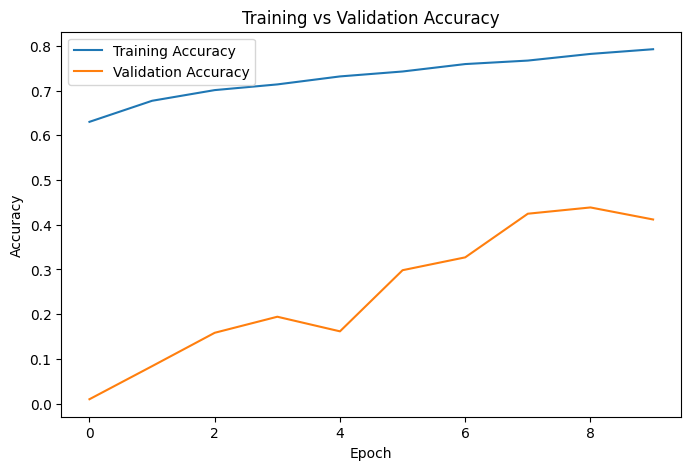

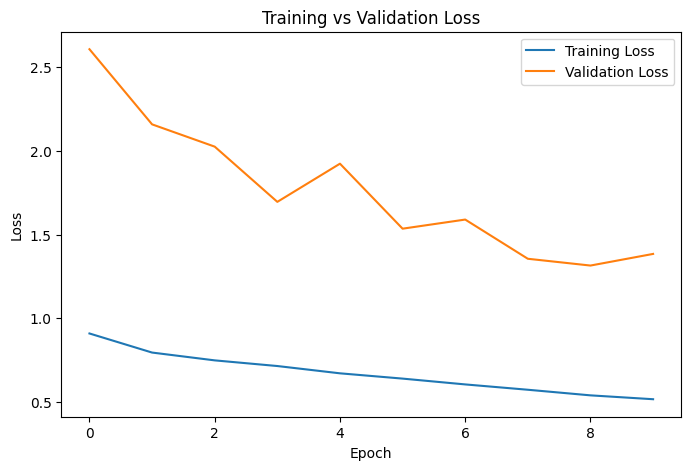

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
    Actual  Predicted
0        0          0
1       -2         -1
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1          1
11       0          0
12      -1         -2
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-2
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,-1
6,I am a new member and hope to find some suppor...,negative,-1,-1
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-1
9,I have mylefibrosis which turn to leukemia the...,negative,-1,-1


In [ ]:
loss, accuracy=w2v_lstm.evaluate(X_test_pad, y_test)
print("Word2Vec+ LSTM Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = w2v_lstm.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob = w2v_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_w2v_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_w2v_lstm.history['loss'], label='Training Loss')
plt.plot(history_w2v_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred = w2v_lstm.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = w2v_lstm.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

# Word2Vec-----GRU

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
w2v_gru = Sequential()
w2v_gru.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)
w2v_gru.add(
    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
w2v_gru.add(Dense(64, activation='relu'))
w2v_gru.add(Dropout(0.5))
w2v_gru.add(Dense(len(np.unique(y)), activation='softmax'))

w2v_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_w2v_gru = w2v_gru.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad,y_test)
)

Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 95s 207ms/step - accuracy: 0.5518 - loss: 1.0526 - val_accuracy: 0.6368 - val_loss: 0.8206
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 141s 205ms/step - accuracy: 0.6577 - loss: 0.8525 - val_accuracy: 0.6474 - val_loss: 0.8106
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 88s 201ms/step - accuracy: 0.6986 - loss: 0.7678 - val_accuracy: 0.6291 - val_loss: 0.8270
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 89s 205ms/step - accuracy: 0.7308 - loss: 0.6923 - val_accuracy: 0.6210 - val_loss: 0.8873
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 89s 204ms/step - accuracy: 0.7567 - loss: 0.6308 - val_accuracy: 0.6787 - val_loss: 0.7569
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 90s 206ms/step - accuracy: 0.7775 - loss: 0.5756 - val_accuracy: 0.6825 - val_loss: 0.7627
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 88s 203ms/step - accuracy: 0.7997 - loss: 0.5209 - val_accuracy: 0.6537 - val_loss: 0.8805
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 88s 203ms/step - accuracy: 0.8154 - loss: 

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6840 - loss: 0.8323
Word2Vec+ GRU Accuracy: 0.6839826703071594
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
Predicted Label: -2
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
              precision    recall  f1-score   support

           0       0.59      0.69      0.63       246
           1       0.66      0.66      0.66       811
           2       0.81      0.73      0.77       889
           3       0.38      0.49      0.43       133

    accuracy                           0.68      2079
   macro avg       0.61      0.64      0.62      2079
weighted avg       0.70      0.68      0.69      2079

[[169  60   3  14]
 [100 537 129  45]
 [ 11 182 651  45]
 [  7  37  24  65]]


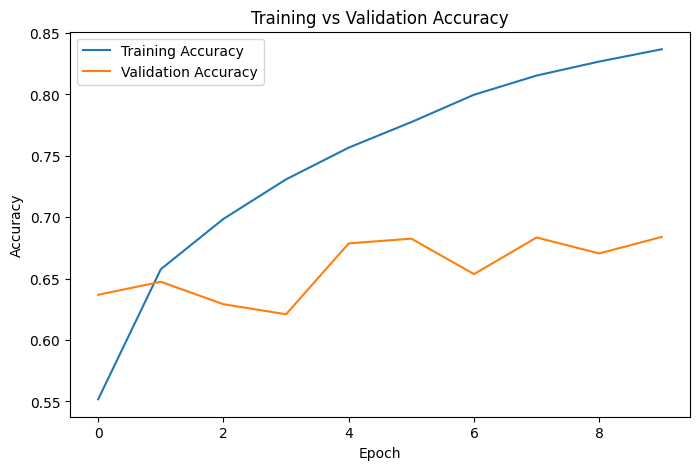

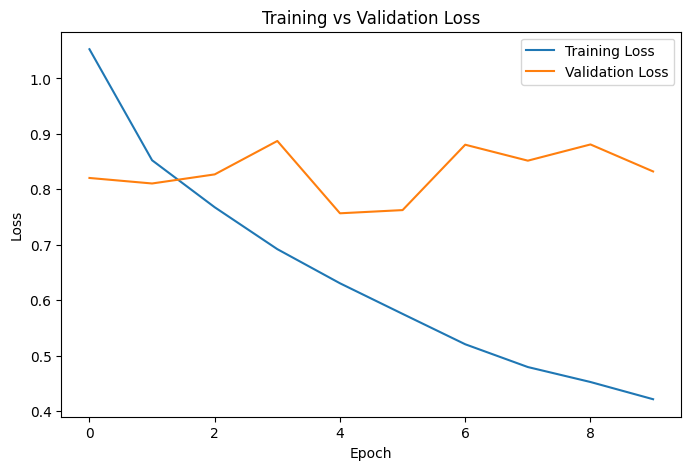

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
    Actual  Predicted
0        0          0
1       -2         -1
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1         -1
11       0          0
12      -1         -1
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-1
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,-1
6,I am a new member and hope to find some suppor...,negative,-1,-1
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-1
9,I have mylefibrosis which turn to leukemia the...,negative,-1,-1


In [ ]:
loss, accuracy =w2v_gru.evaluate(X_test_pad, y_test)
print("Word2Vec+ GRU Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = w2v_gru.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob =w2v_gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_w2v_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v_gru.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_w2v_gru.history['loss'], label='Training Loss')
plt.plot(history_w2v_gru.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred = w2v_gru.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = w2v_gru.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

# Word2Vec----BI-LSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional
w2v_bilstm = Sequential()
w2v_bilstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix_skipgram],
        trainable=False
    )
)
w2v_bilstm.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)
w2v_bilstm.add(Dense(64, activation='relu'))
w2v_bilstm.add(Dropout(0.5))
w2v_bilstm.add(Dense(len(np.unique(y)), activation='softmax'))

w2v_bilstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_w2v_bilstm = w2v_bilstm.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 210s 453ms/step - accuracy: 0.5546 - loss: 1.0503 - val_accuracy: 0.6123 - val_loss: 0.9104
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 194s 444ms/step - accuracy: 0.6259 - loss: 0.9186 - val_accuracy: 0.6551 - val_loss: 0.8077
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 198s 455ms/step - accuracy: 0.6529 - loss: 0.8633 - val_accuracy: 0.6253 - val_loss: 0.8808
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 193s 442ms/step - accuracy: 0.6754 - loss: 0.8087 - val_accuracy: 0.6494 - val_loss: 0.8106
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 209s 458ms/step - accuracy: 0.7033 - loss: 0.7555 - val_accuracy: 0.6335 - val_loss: 0.8306
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 192s 440ms/step - accuracy: 0.7206 - loss: 0.7083 - val_accuracy: 0.6893 - val_loss: 0.7208
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 202s 441ms/step - accuracy: 0.7397 - loss: 0.6616 - val_accuracy: 0.6705 - val_loss: 0.7834
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 203s 443ms/step - accuracy: 0.7631 -

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.6883 - loss: 0.7805
Word2Vec+ Bi-LSTM Accuracy: 0.6883116960525513
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Predicted Label: -2
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
              precision    recall  f1-score   support

           0       0.53      0.87      0.66       246
           1       0.71      0.62      0.66       811
           2       0.84      0.70      0.76       889
           3       0.40      0.65      0.50       133

    accuracy                           0.69      2079
   macro avg       0.62      0.71      0.65      2079
weighted avg       0.72      0.69      0.70      2079

[[213  20   3  10]
 [153 506 102  50]
 [ 24 172 626  67]
 [ 11  19  17  86]]


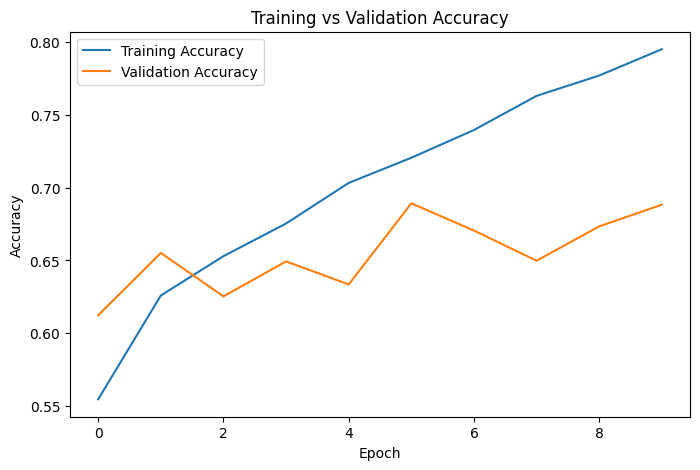

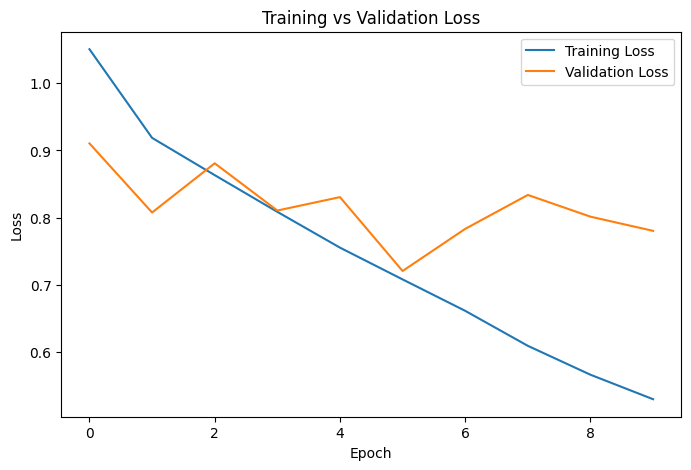

65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step
    Actual  Predicted
0        0          0
1       -2         -2
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1         -2
11       0          0
12      -1         -2
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-2
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,1
6,I am a new member and hope to find some suppor...,negative,-1,-2
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-2
9,I have mylefibrosis which turn to leukemia the...,negative,-1,-1


In [ ]:
loss, accuracy =w2v_bilstm.evaluate(X_test_pad, y_test)
print("Word2Vec+ Bi-LSTM Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = w2v_bilstm.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob =w2v_bilstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_w2v_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_w2v_bilstm.history['loss'], label='Training Loss')
plt.plot(history_w2v_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred = w2v_bilstm.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = w2v_bilstm.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

# GLOVE------LSTM


In [ ]:
import numpy as np

embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Loaded", len(embeddings_index), "word vectors.")

Loaded 29334 word vectors.


In [ ]:
embedding_dim = 100
from tensorflow.keras.preprocessing.text import Tokenizer
word_index = tokenizer.word_index

embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
embedding_dim = 100
max_length = 50

glove_lstm = Sequential()

glove_lstm.add(
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

glove_lstm.add(LSTM(128))

glove_lstm.add(Dropout(0.5))

glove_lstm.add(Dense(64, activation='relu'))

glove_lstm.add(Dense(4, activation='softmax'))   # 4 classes

glove_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_glove_lstm = glove_lstm.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


260/260 ━━━━━━━━━━━━━━━━━━━━ 40s 144ms/step - accuracy: 0.6031 - loss: 0.9366 - val_accuracy: 0.6301 - val_loss: 0.8465
Epoch 2/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step - accuracy: 0.6470 - loss: 0.8235 - val_accuracy: 0.6643 - val_loss: 0.7633
Epoch 3/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 144ms/step - accuracy: 0.6824 - loss: 0.7715 - val_accuracy: 0.6821 - val_loss: 0.7840
Epoch 4/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 39s 148ms/step - accuracy: 0.6874 - loss: 0.7402 - val_accuracy: 0.6965 - val_loss: 0.7153
Epoch 5/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.7019 - loss: 0.7179 - val_accuracy: 0.7061 - val_loss: 0.7245
Epoch 6/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 39s 151ms/step - accuracy: 0.7191 - loss: 0.6891 - val_accuracy: 0.6950 - val_loss: 0.7325
Epoch 7/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 39s 152ms/step - accuracy: 0.7316 - loss: 0.6596 - val_accuracy: 0.7051 - val_loss: 0.7004
Epoch 8/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.7391 - loss: 0.6413 - val

65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7148 - loss: 0.7278
GLOVE + LSTM Accuracy: 0.7147667407989502
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Predicted Label: 1
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step
              precision    recall  f1-score   support

           0       0.80      0.40      0.53       246
           1       0.67      0.75      0.71       811
           2       0.78      0.81      0.79       889
           3       0.49      0.46      0.47       133

    accuracy                           0.71      2079
   macro avg       0.68      0.60      0.63      2079
weighted avg       0.72      0.71      0.71      2079

[[ 98 125  11  12]
 [ 19 607 158  27]
 [  3 141 720  25]
 [  2  36  34  61]]


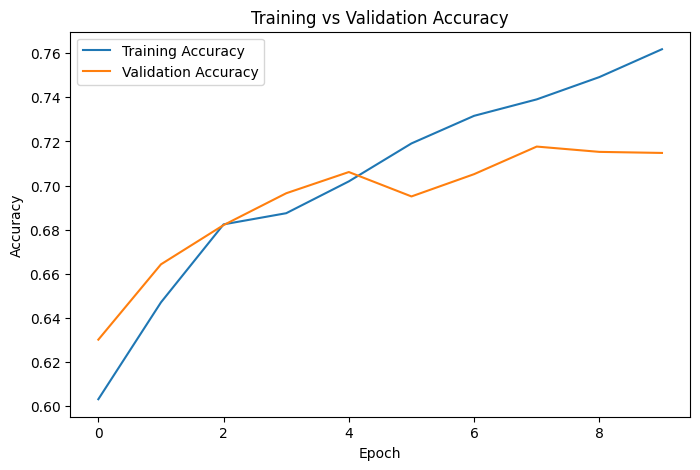

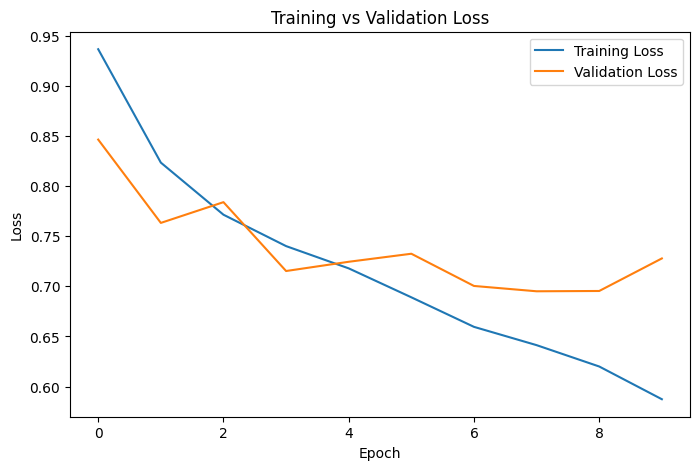

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
    Actual  Predicted
0        0          0
1       -2         -1
2       -2         -1
3        0          0
4        0          0
5        0          0
6       -1         -1
7       -2         -1
8        0          0
9        0          0
10      -1         -1
11       0          0
12      -1         -1
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -1
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-1
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,0
5,mandy is only 24 she is such a sweet friend he...,negative,-1,-1
6,I am a new member and hope to find some suppor...,negative,-1,-1
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-1
9,I have mylefibrosis which turn to leukemia the...,negative,-1,1


In [ ]:
loss, accuracy = glove_lstm.evaluate(X_test_pad, y_test)
print("GLOVE + LSTM Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = glove_lstm.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob =glove_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_glove_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_glove_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_glove_lstm.history['loss'], label='Training Loss')
plt.plot(history_glove_lstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred = glove_lstm.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = glove_lstm.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df


*****GLOVE-------GRU*****

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
glove_gru = Sequential()
glove_gru.add(
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)
glove_gru.add(
    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
glove_gru.add(Dense(64, activation='relu'))
glove_gru.add(Dropout(0.5))
glove_gru.add(Dense(len(np.unique(y)), activation='softmax'))

glove_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_glove_gru = glove_gru.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad,y_test)
)


Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 95s 207ms/step - accuracy: 0.5008 - loss: 1.1308 - val_accuracy: 0.5570 - val_loss: 1.0271
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 139s 201ms/step - accuracy: 0.6334 - loss: 0.9149 - val_accuracy: 0.6445 - val_loss: 0.8297
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 89s 203ms/step - accuracy: 0.6832 - loss: 0.8057 - val_accuracy: 0.6686 - val_loss: 0.7712
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 86s 197ms/step - accuracy: 0.7122 - loss: 0.7328 - val_accuracy: 0.6546 - val_loss: 0.7993
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 144s 201ms/step - accuracy: 0.7462 - loss: 0.6635 - val_accuracy: 0.6445 - val_loss: 0.8230
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 89s 204ms/step - accuracy: 0.7709 - loss: 0.5910 - val_accuracy: 0.6546 - val_loss: 0.8267
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 141s 203ms/step - accuracy: 0.7985 - loss: 0.5353 - val_accuracy: 0.6965 - val_loss: 0.7773
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.8151 - los

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.6825 - loss: 0.8532
GLOVE + GRU Accuracy: 0.682539701461792
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Predicted Label: -2
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
              precision    recall  f1-score   support

           0       0.55      0.77      0.64       246
           1       0.65      0.70      0.68       811
           2       0.85      0.67      0.75       889
           3       0.41      0.50      0.45       133

    accuracy                           0.68      2079
   macro avg       0.62      0.66      0.63      2079
weighted avg       0.71      0.68      0.69      2079

[[189  44   1  12]
 [119 571  84  37]
 [ 20 228 592  49]
 [ 14  34  18  67]]


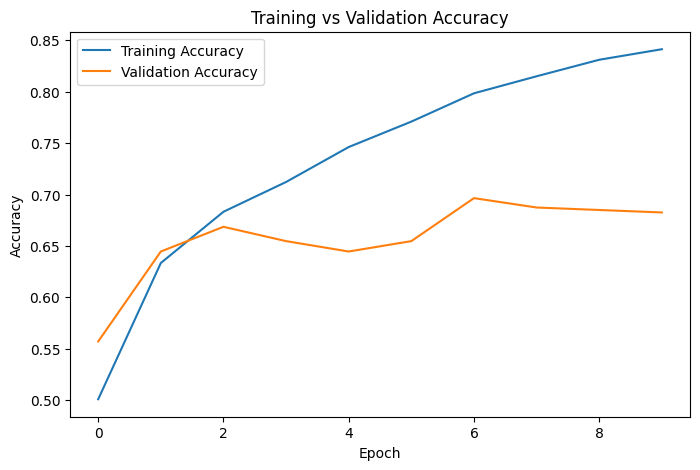

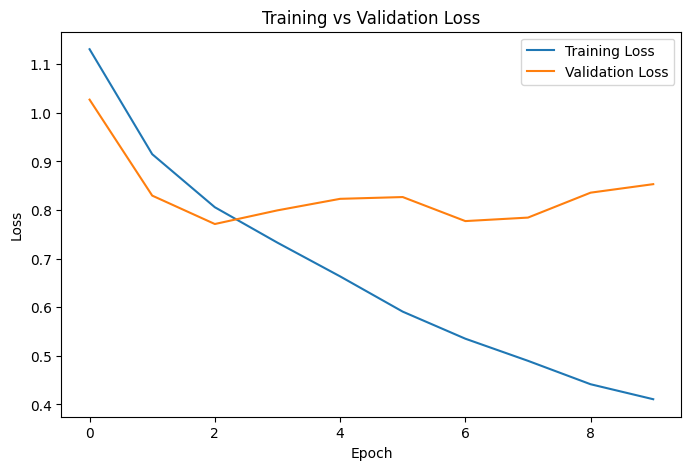

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
    Actual  Predicted
0        0          0
1       -2         -2
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -1
8        0          0
9        0          1
10      -1         -1
11       0          0
12      -1         -1
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-2
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,-1
6,I am a new member and hope to find some suppor...,negative,-1,-1
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-2
9,I have mylefibrosis which turn to leukemia the...,negative,-1,0


In [ ]:

loss, accuracy =glove_gru.evaluate(X_test_pad, y_test)
print("GLOVE + GRU Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = glove_gru.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob =glove_gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_glove_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_glove_gru.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_glove_gru.history['loss'], label='Training Loss')
plt.plot(history_glove_gru.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred =glove_gru.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = glove_gru.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df


**GLOVE-------BI-LSTM**

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
glove_bilstm = Sequential()
glove_bilstm.add(
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)
glove_bilstm.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)
glove_bilstm.add(Dense(64, activation='relu'))
glove_bilstm.add(Dropout(0.5))
glove_bilstm.add(Dense(len(np.unique(y)), activation='softmax'))

glove_bilstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_glove_bilstm = glove_bilstm.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)


In [ ]:

loss, accuracy = glove_bilstm.evaluate(X_test_pad, y_test)
print("GLOVE + Bi-LSTM Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = glove_bilstm.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob =glove_bilstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_glove_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_glove_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_glove_bilstm.history['loss'], label='Training Loss')
plt.plot(history_glove_bilstm.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred = glove_bilstm.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = glove_bilstm.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df

In [ ]:
glove_gru.save("glove_gru.keras")

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)